In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [3]:
# load dataset
crss_combined = pd.read_csv("crss_combined.csv")

# EDA

In [4]:
# create person base
crss_combined_person = (
    crss_combined.assign(
        DRINKING_T=lambda x: np.where(x["DRINKING"]==1,1,0),
        DRINKING_F=lambda x: np.where(x["DRINKING"]==0,1,0),
        DRUGS_T=lambda x: np.where(x["DRUGS"]==1,1,0),
        DRUGS_F=lambda x: np.where(x["DRUGS"]==0,1,0),
        FATAL=lambda x:np.where(x["INJ_SEV"]==4,1,0)
    )
    .groupby("CASENUM",as_index=False)
    .agg(
        WEIGHT = ("WEIGHT","mean"),
        DRINKING_T=("DRINKING_T", "mean"),
        DRINKING_F=("DRINKING_F", "mean"),
        DRUGS_T=("DRUGS_T", "mean"),
        DRUGS_F=("DRUGS_F", "mean"),
        FATAL=("FATAL", "mean"),
        AGE=("AGE", "mean")
    )
)

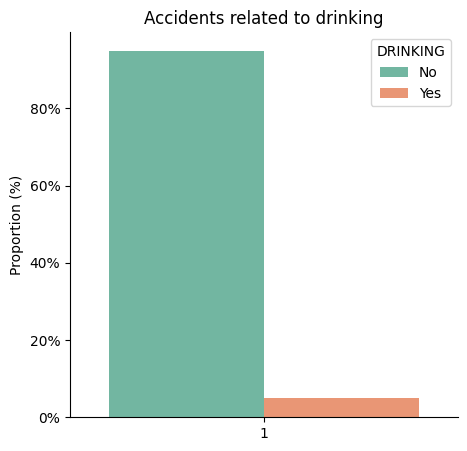

In [5]:
df_drinking = crss_combined_person.copy()
# Binarize indicators
df_drinking["DRINKING_T"] = np.where(df_drinking["DRINKING_T"] > 0, 1, 0)
df_drinking["DRINKING_F"] = np.where(df_drinking["DRINKING_T"] == 1, 0, df_drinking["DRINKING_F"])
df_drinking["DRINKING_F"] = np.where(df_drinking["DRINKING_F"] > 0, 1, 0)
df_drinking["DRINKING_NA"] = np.where(df_drinking[["DRINKING_T","DRINKING_F"]].isna().any(axis=1), 1, 0)

# Pivot longer equivalent
df_drinking_long = df_drinking.melt(id_vars=["CASENUM","WEIGHT"], 
                                    value_vars=["DRINKING_T","DRINKING_F"], 
                                    var_name="name", value_name="value")
df_drinking_long = df_drinking_long[df_drinking_long["value"] == 1]
df_drinking_long["DRINKING"] = df_drinking_long["name"].map({"DRINKING_T":"Yes", "DRINKING_F":"No"})

# Summarize
drinking_summary = df_drinking_long.groupby("DRINKING", as_index=False).agg(TOTAL=("WEIGHT","sum"))
drinking_summary["PROP"] = drinking_summary["TOTAL"] / drinking_summary["TOTAL"].sum()

plt.figure(figsize=(5,5))
ax = sns.barplot(data=drinking_summary, x=[1]*len(drinking_summary), y="PROP", hue="DRINKING", palette="Set2")

# Set y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # 1.0 means the data is 0-1

plt.ylabel("Proportion (%)")
plt.title("Accidents related to drinking")
sns.despine()
plt.show()

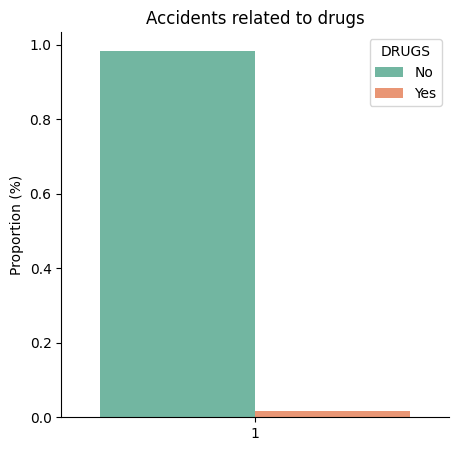

In [6]:
df_drugs = crss_combined_person.copy()
df_drugs["DRUGS_T"] = np.where(df_drugs["DRUGS_T"] > 0, 1, 0)
df_drugs["DRUGS_F"] = np.where(df_drugs["DRUGS_T"] == 1, 0, df_drugs["DRUGS_F"])
df_drugs["DRUGS_F"] = np.where(df_drugs["DRUGS_F"] > 0, 1, 0)
df_drugs["DRUGS_NA"] = np.where(df_drugs[["DRUGS_T","DRUGS_F"]].isna().any(axis=1), 1, 0)

df_drugs_long = df_drugs.melt(id_vars=["CASENUM","WEIGHT"],
                               value_vars=["DRUGS_T","DRUGS_F"],
                               var_name="name", value_name="value")
df_drugs_long = df_drugs_long[df_drugs_long["value"] == 1]
df_drugs_long["DRUGS"] = df_drugs_long["name"].map({"DRUGS_T":"Yes", "DRUGS_F":"No"})

drugs_summary = df_drugs_long.groupby("DRUGS", as_index=False).agg(TOTAL=("WEIGHT","sum"))
drugs_summary["PROP"] = drugs_summary["TOTAL"] / drugs_summary["TOTAL"].sum()

# Plot
plt.figure(figsize=(5,5))
sns.barplot(data=drugs_summary, x=[1]*len(drugs_summary), y="PROP", hue="DRUGS", palette="Set2")

# Set y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # 1.0 means the data is 0-1

plt.ylabel("Proportion (%)")
plt.title("Accidents related to drugs")
sns.despine()
plt.show()

In [7]:
fatal_summary = (
    crss_combined_person.assign(FATAL=lambda x: np.where(x["FATAL"]>0,"Yes","No"))
    .groupby("FATAL", as_index=False)
    .agg(TOTAL=("WEIGHT","sum"))
)
fatal_summary["PROP"] = fatal_summary["TOTAL"] / fatal_summary["TOTAL"].sum()
fatal_summary

,FATAL,TOTAL,PROP
0,No,4.989174e+07,0.994656
1,Yes,2.680541e+05,0.005344


/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_25664/2894506340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=age_summary, x="AGE", y="TOTAL", palette="Blues_r")


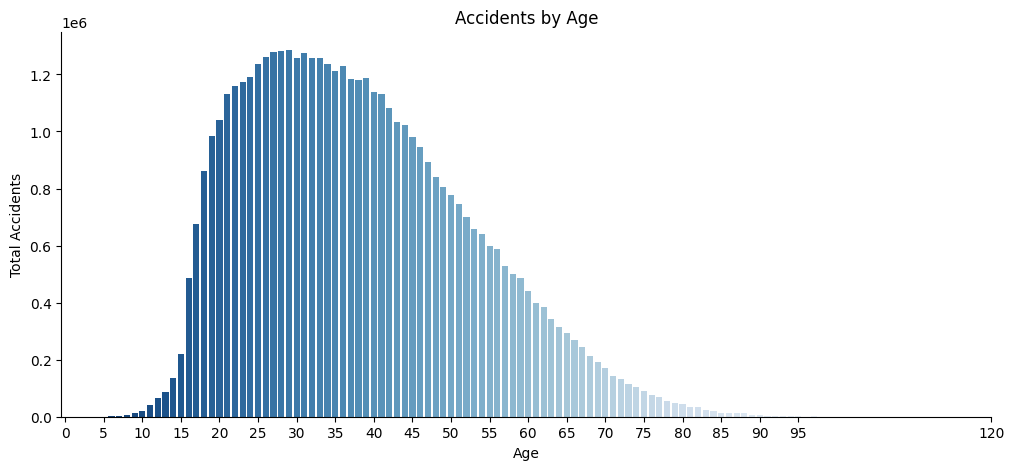

In [8]:
age_summary = (
    crss_combined_person.assign(AGE=lambda x: np.floor(x["AGE"]))
    .groupby("AGE", as_index=False)
    .agg(TOTAL=("WEIGHT","sum"))
)

plt.figure(figsize=(12,5))
ax = sns.barplot(data=age_summary, x="AGE", y="TOTAL", palette="Blues_r")

# Only show every 5 years on x-axis
ticks_to_show = age_summary["AGE"][age_summary["AGE"] % 5 == 0]
plt.xticks(ticks=ticks_to_show, labels=[int(x) for x in ticks_to_show])

plt.xlabel("Age")
plt.ylabel("Total Accidents")
plt.title("Accidents by Age")
sns.despine()
plt.show()

In [9]:
# create accident base
crss_combined_accident = (
    crss_combined[
        [
            "ID","CASENUM","URBANICITY","REGION","WEIGHT","YEAR",
            "VE_TOTAL","MONTH","DAY_WEEK","HOUR","RELJCT2",
            "TYP_INT","LGT_COND","WEATHER"
        ]
    ]
    .drop_duplicates()
)

In [10]:
# assess null values

null_summary = (
    crss_combined_accident.isna().sum()
    .reset_index()
    .rename(columns={"index":"variable",0:"n_na"})
)

null_summary["n"] = len(crss_combined_accident)
null_summary["p_na"]=null_summary["n_na"]/null_summary["n"]
null_summary = null_summary.sort_values("p_na",ascending=False)

In [11]:
null_summary

,variable,n_na,n,p_na
11,TYP_INT,31384,417195,0.075226
10,RELJCT2,19995,417195,0.047927
13,WEATHER,18284,417195,0.043826
12,LGT_COND,2954,417195,0.007081
9,HOUR,2202,417195,0.005278
0,ID,0,417195,0.000000
5,YEAR,0,417195,0.000000
4,WEIGHT,0,417195,0.000000
3,REGION,0,417195,0.000000
2,URBANICITY,0,417195,0.000000


In [12]:
# auxiliar functions
def days_in_month(row):
    """Function to give the number of days per month in timeframe considered"""
    if row["MONTH"] in [4,6,9,11]:
        return 30
    elif row["MONTH"] in [1,3,5,7,8,10,12]:
        return 31
    elif row["YEAR"] in [2016,2020]:
        return 29
    else:
        return 28

def summarize_by(df, group_vars, value_col="WEIGHT", normalize_days=False, avg_over=None):
    """
    Generic function to compute total or day-averaged accident counts.

    Parameters
    ----------
    df : pd.DataFrame
        Accident data.
    group_vars : list
        Variables to group by (e.g. ['YEAR', 'DAY_WEEK']).
    value_col : str
        Column to sum (default 'WEIGHT').
    normalize_days : bool
        If True, divide totals by days in month.
    avg_over : str or None
        If provided, average the day-averages over this variable (e.g. 'MONTH').

    Returns
    -------
    pd.DataFrame
    """
    result = (
        df.groupby(group_vars, as_index=False)
        .agg(TOTAL=(value_col, "sum"))
    )

    if normalize_days:
        # add days in month
        if "MONTH" not in df.columns:
            raise ValueError("normalize_days=True requires MONTH column in df.")
        result["days"] = result.apply(days_in_month, axis=1)
        result["DAY_AVERAGE"] = result["TOTAL"] / result["days"]

        if avg_over:
            # average over specified variable (e.g., MONTH)
            result = (
                result.groupby([v for v in group_vars if v != avg_over], as_index=False)
                .agg(DAY_AVERAGE=("DAY_AVERAGE", "mean"))
            )

    return result

def plot_trend(data, x, y, hue="YEAR", title=None, ylabel=None):
    """Generic line plot function."""
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker="o")
    sns.despine()
    plt.title(title or f"{y} by {x} and {hue}")
    plt.xlabel(x)
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

def plot_box(data, x, y, title=None, ylabel=None):
    """Generic boxplot for categorical accident summaries."""
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=x, y=y, palette="tab10")
    sns.despine()
    plt.title(title or f"{y} by {x}")
    plt.xlabel(x)
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

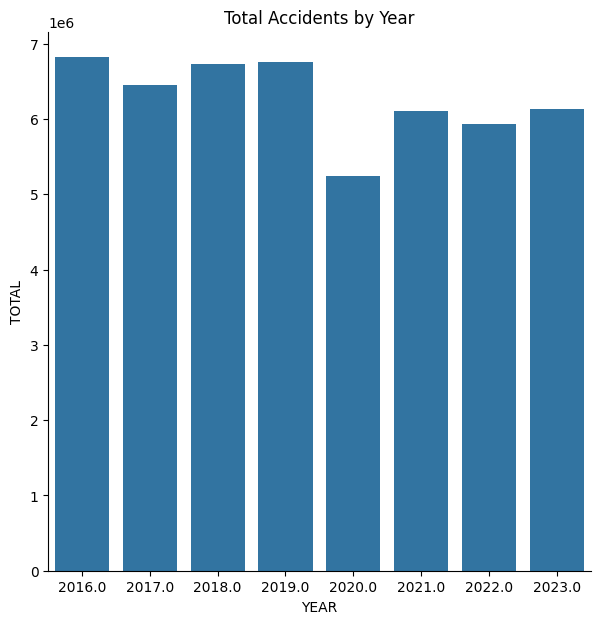

In [21]:
year_totals = (
    crss_combined_accident
    .groupby("YEAR",as_index=False)
    .agg(TOTAL=("WEIGHT","sum"))

)

plt.figure(figsize=(7,7))
sns.barplot(data=year_totals, x="YEAR", y="TOTAL")


plt.ylabel("TOTAL")
plt.title("Total Accidents by Year")
sns.despine()
plt.show()

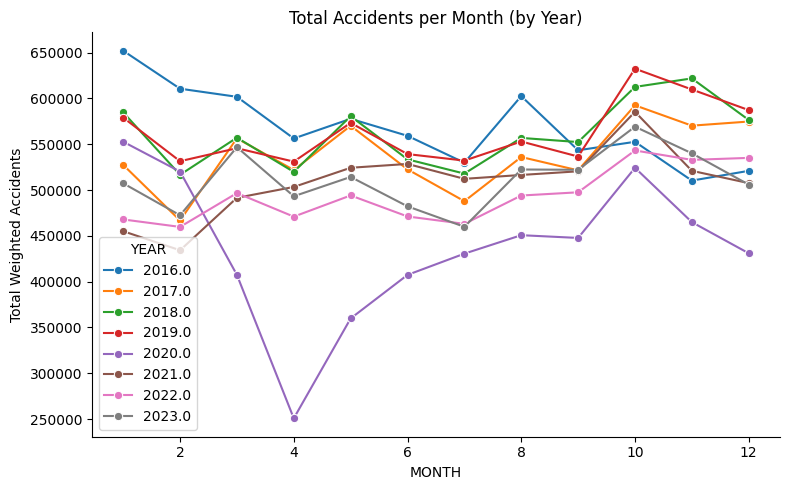

In [68]:
# total accidents across US per month for different years
month_totals = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH"]
)

month_totals["YEAR"] = month_totals["YEAR"].astype(str)

plot_trend(
    month_totals,
    x="MONTH",
    y="TOTAL",
    title="Total Accidents per Month (by Year)",
    ylabel="Total Weighted Accidents"
)

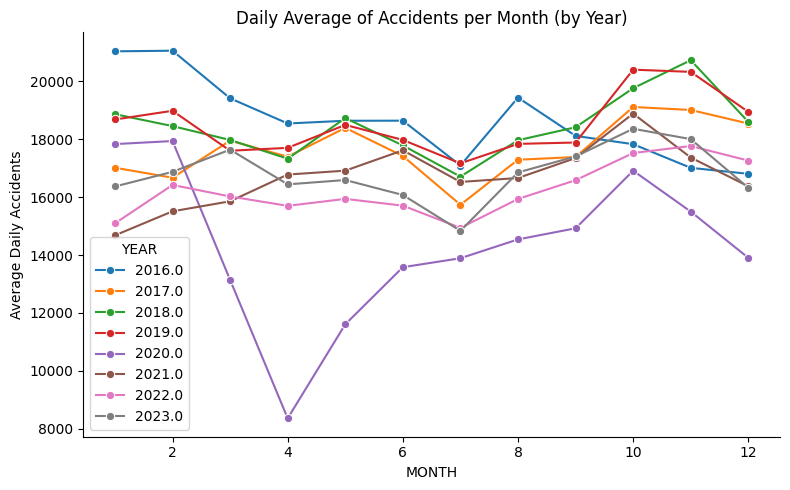

In [66]:
month_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH"],
    normalize_days=True
)

month_avg["YEAR"] = month_avg["YEAR"].astype(str)

plot_trend(
    month_avg,
    x="MONTH",
    y="DAY_AVERAGE",
    title="Daily Average of Accidents per Month (by Year)",
    ylabel="Average Daily Accidents"
)


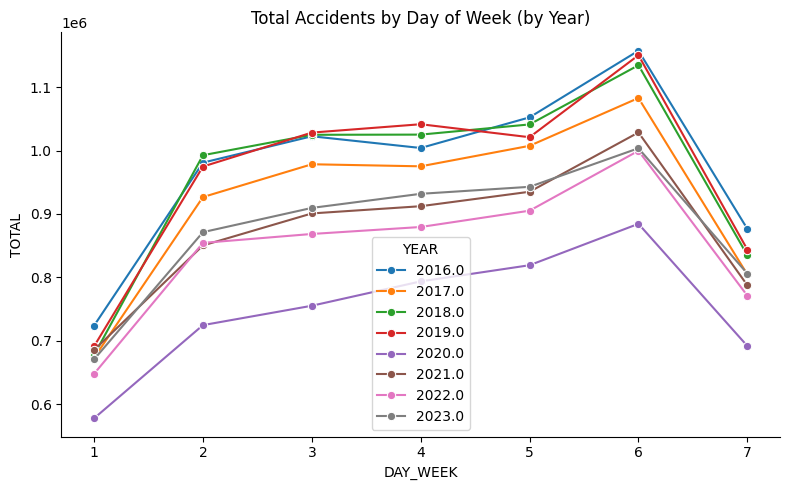

In [65]:
dayweek_totals = summarize_by(crss_combined_accident, ["YEAR", "DAY_WEEK"])

dayweek_totals["YEAR"] = dayweek_totals["YEAR"].astype(str)

plot_trend(
    dayweek_totals,
    x="DAY_WEEK", y="TOTAL",
    title="Total Accidents by Day of Week (by Year)"
)

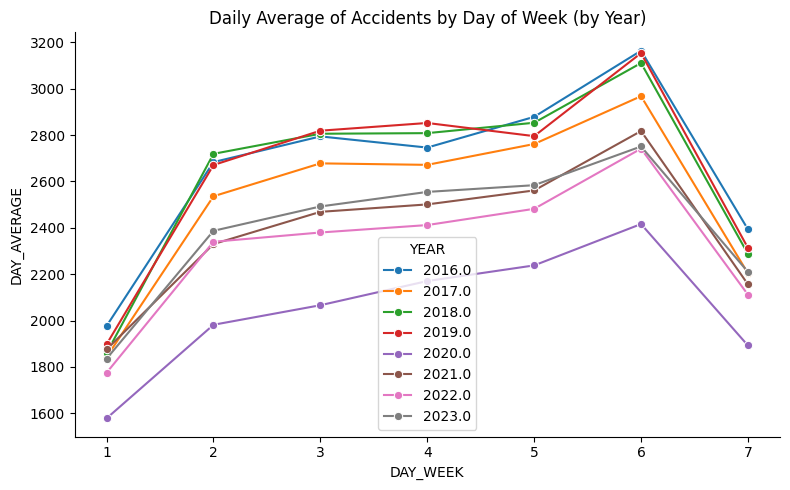

In [60]:
dayweek_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "DAY_WEEK"],
    normalize_days=True,
    avg_over="MONTH"
)

dayweek_avg["YEAR"] = dayweek_avg["YEAR"].astype(str)

plot_trend(
    dayweek_avg,
    x="DAY_WEEK", y="DAY_AVERAGE",
    title="Daily Average of Accidents by Day of Week (by Year)"
)

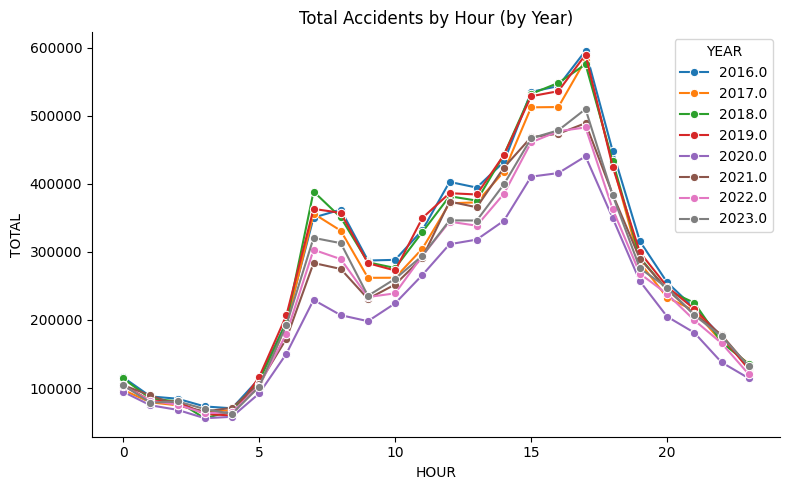

In [63]:
hour_totals = summarize_by(crss_combined_accident, ["YEAR", "HOUR"])

hour_totals["YEAR"] = hour_totals["YEAR"].astype(str)

plot_trend(
    hour_totals,
    x="HOUR", y="TOTAL",
    title="Total Accidents by Hour (by Year)"
)

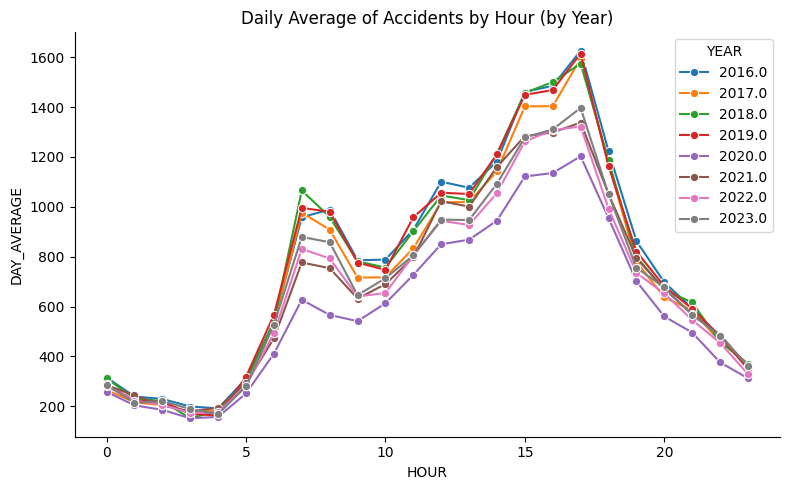

In [64]:
hour_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "HOUR"],
    normalize_days=True,
    avg_over="MONTH"
)

hour_avg["YEAR"] = hour_avg["YEAR"].astype(str)

plot_trend(
    hour_avg,
    x="HOUR", y="DAY_AVERAGE",
    title="Daily Average of Accidents by Hour (by Year)"
)

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


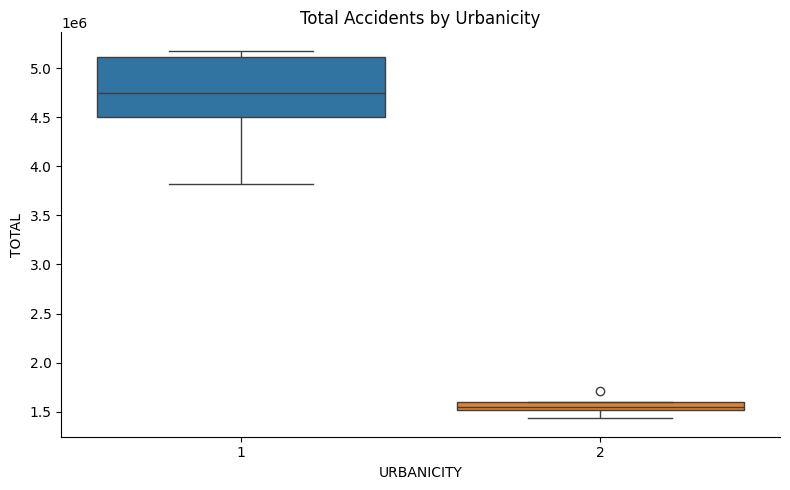

In [70]:
urbanicity_total = summarize_by(crss_combined_accident, ["YEAR", "URBANICITY"])

plot_box(
    urbanicity_total,
    x="URBANICITY",
    y="TOTAL",
    title="Total Accidents by Urbanicity"
)

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


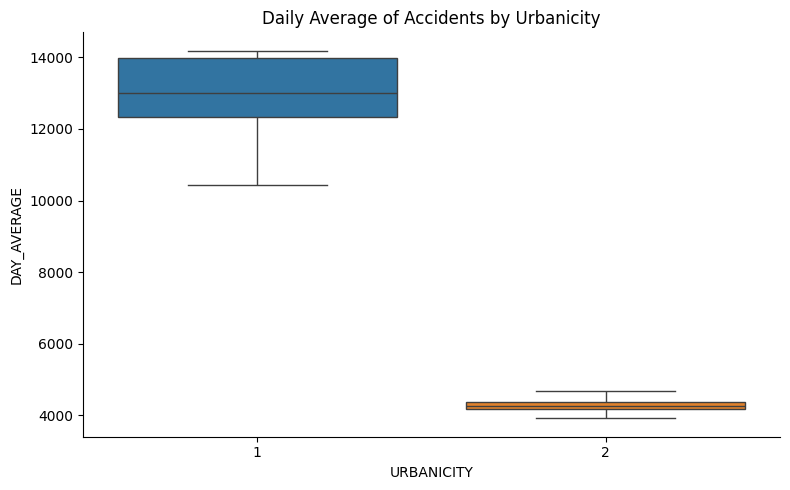

In [71]:
urbanicity_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "URBANICITY"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(
    urbanicity_avg,
    x="URBANICITY",
    y="DAY_AVERAGE",
    title="Daily Average of Accidents by Urbanicity"
)

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


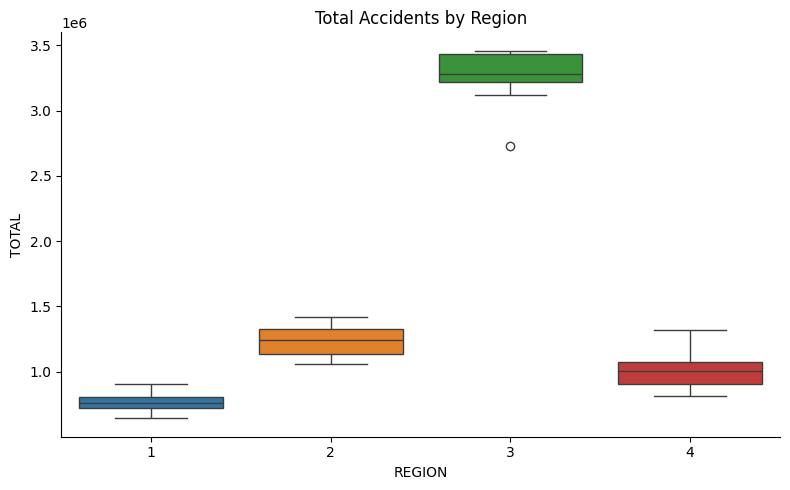

In [73]:
region_total = summarize_by(crss_combined_accident, ["YEAR", "REGION"])
plot_box(region_total, x="REGION", y="TOTAL", title="Total Accidents by Region")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


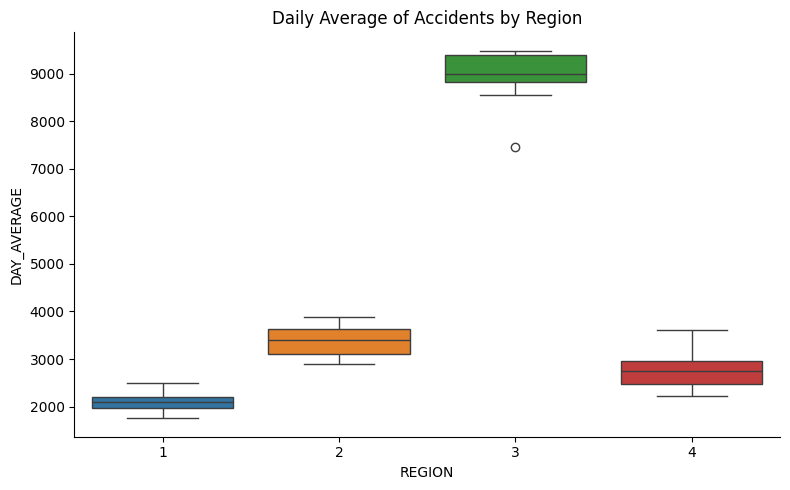

In [74]:
region_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "REGION"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(region_avg, x="REGION", y="DAY_AVERAGE", title="Daily Average of Accidents by Region")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


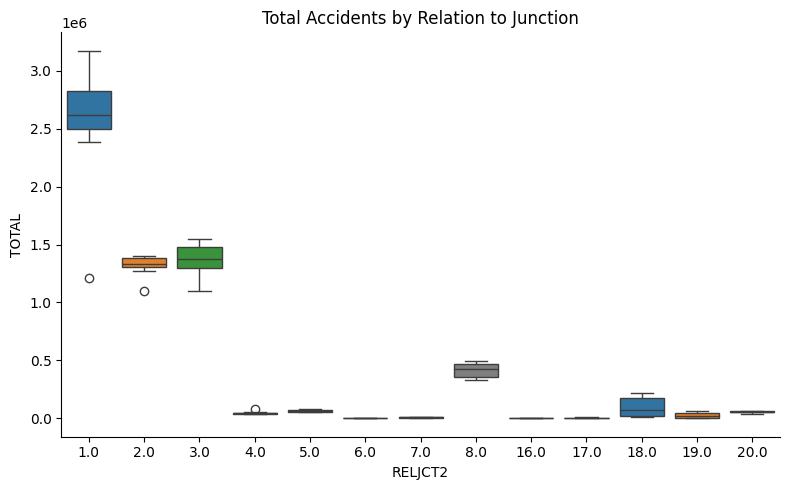

In [75]:
reljct_total = summarize_by(crss_combined_accident, ["YEAR", "RELJCT2"])
plot_box(reljct_total, x="RELJCT2", y="TOTAL", title="Total Accidents by Relation to Junction")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


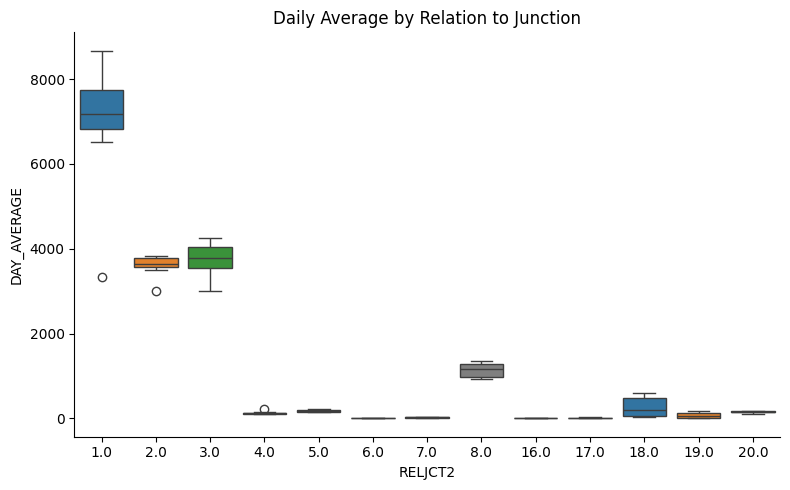

In [76]:

reljct_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "RELJCT2"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(reljct_avg, x="RELJCT2", y="DAY_AVERAGE", title="Daily Average by Relation to Junction")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


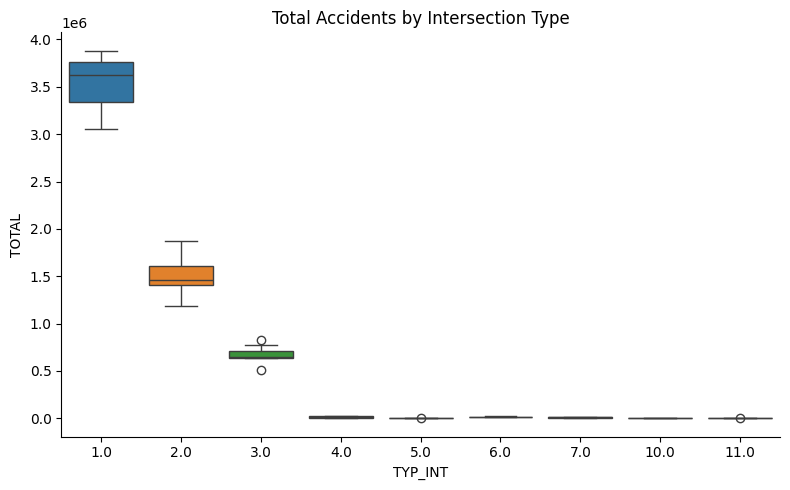

In [77]:
typint_total = summarize_by(crss_combined_accident, ["YEAR", "TYP_INT"])
plot_box(typint_total, x="TYP_INT", y="TOTAL", title="Total Accidents by Intersection Type")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


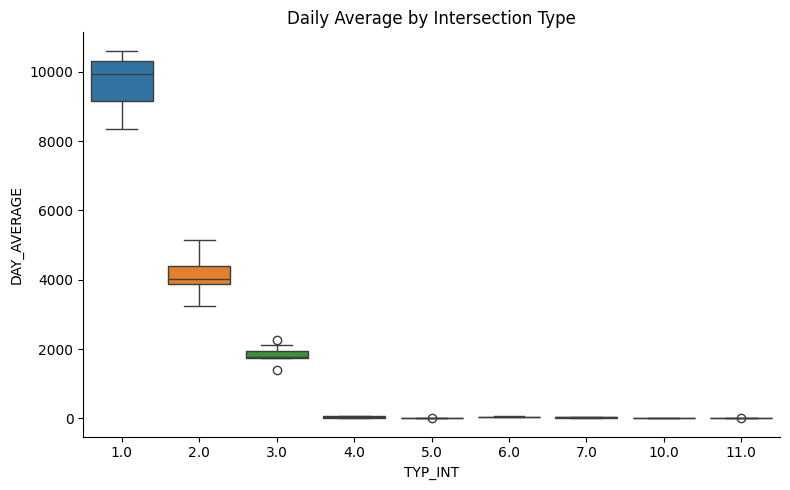

In [78]:
typint_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "TYP_INT"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(typint_avg, x="TYP_INT", y="DAY_AVERAGE", title="Daily Average by Intersection Type")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


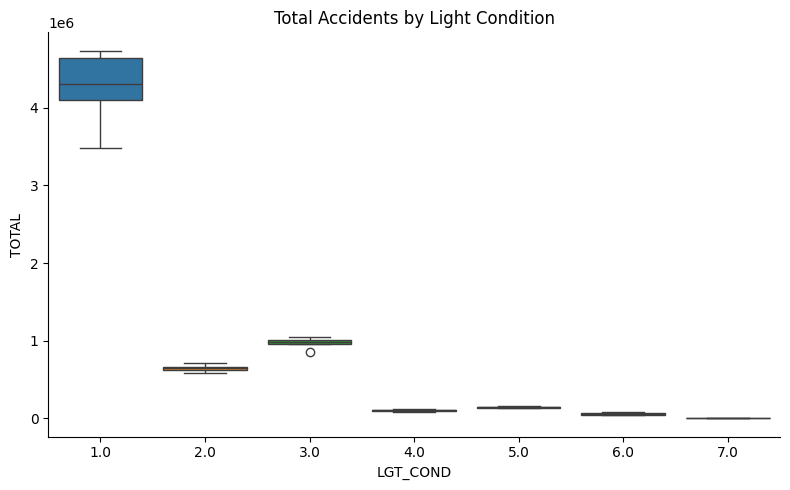

In [80]:
lgtcond_total = summarize_by(crss_combined_accident, ["YEAR", "LGT_COND"])
plot_box(lgtcond_total, x="LGT_COND", y="TOTAL", title="Total Accidents by Light Condition")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


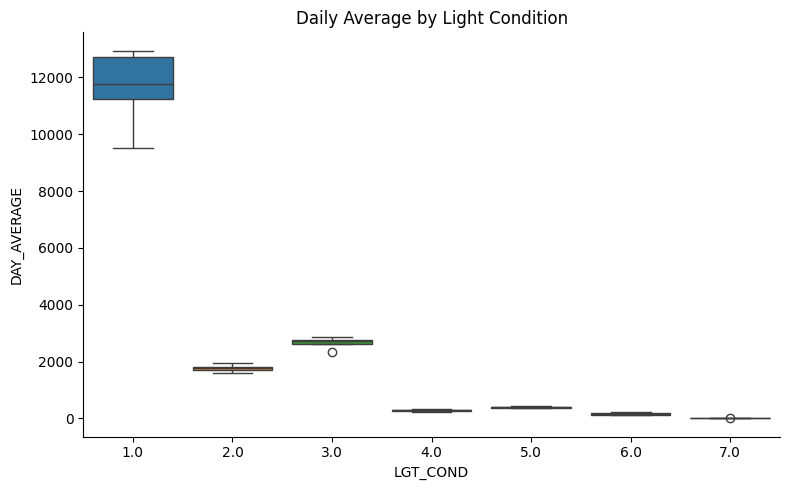

In [82]:
lgtcond_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "LGT_COND"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(lgtcond_avg, x="LGT_COND", y="DAY_AVERAGE", title="Daily Average by Light Condition")

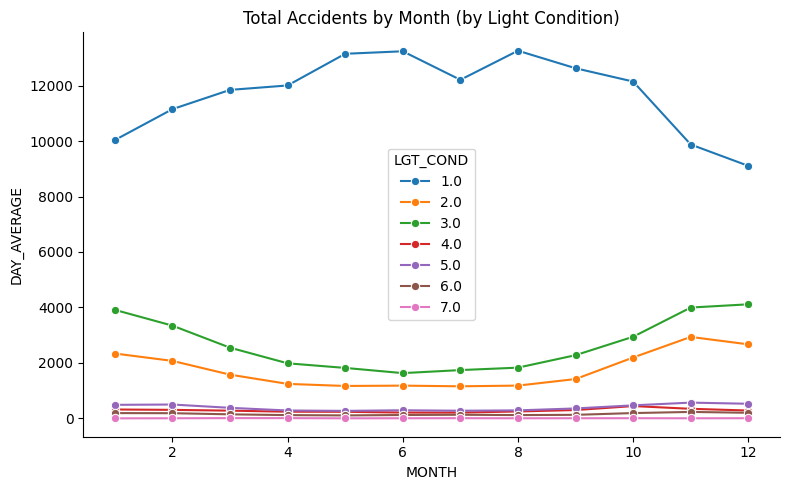

In [89]:
lgtcond_avg2 = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "LGT_COND"],
    normalize_days=True,
    avg_over="YEAR"
)

lgtcond_avg2["LGT_COND"] = lgtcond_avg2["LGT_COND"].astype(str)

plot_trend(
    lgtcond_avg2,
    x="MONTH", y="DAY_AVERAGE",hue="LGT_COND",
    title="Total Accidents by Month (by Light Condition)"
)


/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


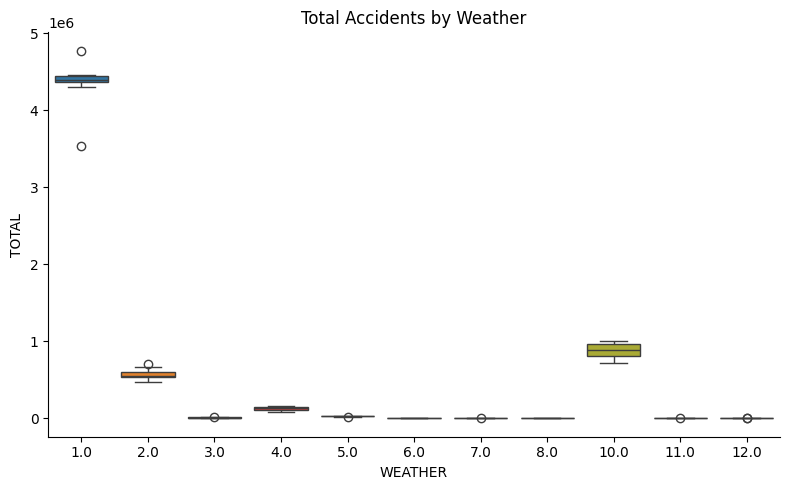

In [90]:
weather_total = summarize_by(crss_combined_accident, ["YEAR", "WEATHER"])
plot_box(weather_total, x="WEATHER", y="TOTAL", title="Total Accidents by Weather")

/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21079/860334687.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette="tab10")


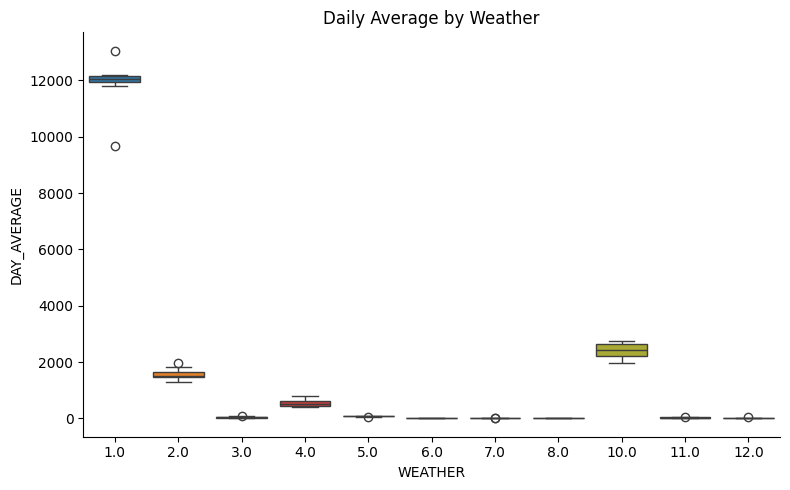

In [91]:
lgtcond_avg = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "WEATHER"],
    normalize_days=True,
    avg_over="MONTH"
)
plot_box(lgtcond_avg, x="WEATHER", y="DAY_AVERAGE", title="Daily Average by Weather")

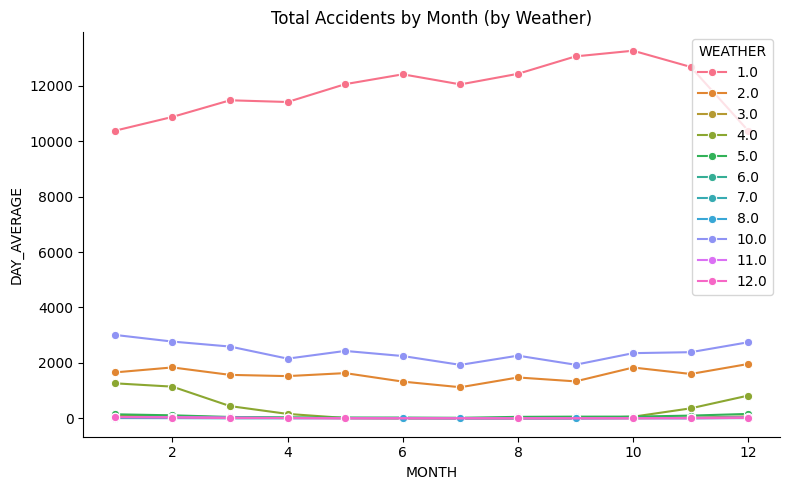

In [92]:
lgtcond_avg2 = summarize_by(
    crss_combined_accident,
    ["YEAR", "MONTH", "WEATHER"],
    normalize_days=True,
    avg_over="YEAR"
)

lgtcond_avg2["WEATHER"] = lgtcond_avg2["WEATHER"].astype(str)

plot_trend(
    lgtcond_avg2,
    x="MONTH", y="DAY_AVERAGE",hue="WEATHER",
    title="Total Accidents by Month (by Weather)"
)

In [106]:
# create vehicle base
crss_combined_vehicle = (
    crss_combined[["CASENUM","VEH_NO","WEIGHT","P_CRASH1"]]
    .drop_duplicates()
)

# Modeling

In [108]:
# Define LEFT, RIGHT, STRAIGHT
LEFT = crss_combined_vehicle.loc[crss_combined_vehicle["P_CRASH1"]==11, ["CASENUM"]].drop_duplicates()
RIGHT = crss_combined_vehicle.loc[crss_combined_vehicle["P_CRASH1"]==10, ["CASENUM"]].drop_duplicates()
STRAIGHT = crss_combined_vehicle.loc[crss_combined_vehicle["P_CRASH1"]==1, ["CASENUM"]].drop_duplicates()

In [144]:
def comparison_f(df1, df2, var, k=1, data=crss_combined_accident):
    """
    Compare total accidents for df1 vs df2 across a categorical variable var.

    Parameters
    ----------
    df1, df2 : pd.DataFrame
        Vehicle subsets with CASENUM
    var : str
        Column name in data to group by
    k : float
        Scaling factor
    data : pd.DataFrame
        Accident-level data with WEIGHT and CASENUM
    """

    # Drop rows where TYP_INT is NA
    data = data.dropna(subset=["TYP_INT"])
    
    values = sorted(data[var].dropna().unique())

    # Baseline totals
    a0 = data.loc[data["TYP_INT"]!=1].merge(df1,on="CASENUM")["WEIGHT"].sum()
    b0 = data.loc[data["TYP_INT"]!=1].merge(df2,on="CASENUM")["WEIGHT"].sum()
    baseline = a0 / b0 * k if b0 != 0 else np.nan

    results = []

    for val in values:
        a = data.loc[(data["TYP_INT"] != 1) & (data[var]==val)].merge(df1, on="CASENUM")["WEIGHT"].sum()
        b = data.loc[(data["TYP_INT"] != 1) & (data[var]==val)].merge(df2, on="CASENUM")["WEIGHT"].sum()
        ratio = a / b * k if b != 0 else np.nan
        above_baseline = ratio > baseline * 1.01 if not np.isnan(ratio) else np.nan

        results.append({
            var: val,
            "total_df1": a,
            "total_df2": b,
            "baseline": baseline,
            "ratio": ratio,
            "above_baseline": above_baseline
        })

    return pd.DataFrame(results)

In [146]:
comparison_f(LEFT, RIGHT, "MONTH")

,MONTH,total_df1,total_df2,baseline,ratio,above_baseline
0,1,488648.453815,175615.153157,2.790035,2.782496,False
1,2,439347.828894,163622.728217,2.790035,2.685127,False
2,3,475779.430518,169180.838757,2.790035,2.812254,False
3,4,425328.196447,156763.979163,2.790035,2.713176,False
4,5,460230.017883,161651.196800,2.790035,2.847056,True
5,6,447600.152278,165976.568877,2.790035,2.696767,False
6,7,426083.527962,152639.313247,2.790035,2.791440,False
7,8,475229.736726,170616.948711,2.790035,2.785361,False
8,9,483115.872806,171939.859805,2.790035,2.809796,False
9,10,530015.483187,185647.659421,2.790035,2.854954,True


In [147]:
comparison_f(LEFT, RIGHT, "DAY_WEEK")

,DAY_WEEK,total_df1,total_df2,baseline,ratio,above_baseline
0,1,529987.741536,191803.986565,2.790035,2.763174,False
1,2,799122.699970,300766.821097,2.790035,2.656951,False
2,3,857721.138511,315702.992807,2.790035,2.716861,False
3,4,874587.795390,318513.975941,2.790035,2.745838,False
4,5,899547.880061,306839.722125,2.790035,2.931654,True
5,6,980946.147829,344103.112811,2.790035,2.850733,True
6,7,685841.298028,239360.189012,2.790035,2.865311,True


In [148]:
comparison_f(LEFT, RIGHT, "HOUR")

,HOUR,total_df1,total_df2,baseline,ratio,above_baseline
0,0.0,61541.905168,26039.609309,2.790035,2.363396,False
1,1.0,36673.142935,18859.909733,2.790035,1.944503,False
2,2.0,34273.306542,15390.425709,2.790035,2.226924,False
3,3.0,25780.493862,10786.089016,2.790035,2.390161,False
4,4.0,24796.277489,8477.371562,2.790035,2.924996,True
5,5.0,59043.683234,22569.705618,2.790035,2.616059,False
6,6.0,151672.347229,56736.046251,2.790035,2.673298,False
7,7.0,297572.723741,107202.482567,2.790035,2.775801,False
8,8.0,265221.714318,107122.897981,2.790035,2.475864,False
9,9.0,224886.159563,91214.223467,2.790035,2.465472,False


In [149]:
comparison_f(LEFT, RIGHT, "LGT_COND")

,LGT_COND,total_df1,total_df2,baseline,ratio,above_baseline
0,1.0,4.023282e+06,1.494023e+06,2.790035,2.692918,False
1,2.0,2.662595e+05,9.062711e+04,2.790035,2.937968,True
2,3.0,1.077773e+06,3.395726e+05,2.790035,3.173912,True
3,4.0,7.194297e+04,2.617278e+04,2.790035,2.748771,False
4,5.0,1.417744e+05,4.631951e+04,2.790035,3.060793,True
5,6.0,3.259679e+04,1.127026e+04,2.790035,2.892285,True
6,7.0,4.688051e+02,5.835632e+02,2.790035,0.803349,False


In [150]:
comparison_f(LEFT, RIGHT, "WEATHER")

,WEATHER,total_df1,total_df2,baseline,ratio,above_baseline
0,1.0,4.103846e+06,1.441261e+06,2.790035,2.847400,True
1,2.0,4.657540e+05,1.656382e+05,2.790035,2.811875,False
2,3.0,3.993524e+03,1.259252e+03,2.790035,3.171347,True
3,4.0,6.321260e+04,4.702108e+04,2.790035,1.344346,False
4,5.0,1.512288e+04,5.627363e+03,2.790035,2.687382,False
5,6.0,2.701062e+03,9.916157e+02,2.790035,2.723900,False
6,7.0,7.795831e+02,2.827260e+02,2.790035,2.757380,False
7,8.0,2.926264e+03,9.050286e+02,2.790035,3.233339,True
8,10.0,7.561677e+05,2.791524e+05,2.790035,2.708799,False
9,11.0,1.674919e+03,1.291486e+03,2.790035,1.296893,False


In [151]:
comparison_f(LEFT, STRAIGHT, "MONTH")

,MONTH,total_df1,total_df2,baseline,ratio,above_baseline
0,1,488648.453815,1.127741e+06,0.417243,0.433298,True
1,2,439347.828894,1.059717e+06,0.417243,0.414590,False
2,3,475779.430518,1.150160e+06,0.417243,0.413664,False
3,4,425328.196447,1.065985e+06,0.417243,0.399000,False
4,5,460230.017883,1.130050e+06,0.417243,0.407265,False
5,6,447600.152278,1.083150e+06,0.417243,0.413239,False
6,7,426083.527962,1.056180e+06,0.417243,0.403419,False
7,8,475229.736726,1.160619e+06,0.417243,0.409462,False
8,9,483115.872806,1.146810e+06,0.417243,0.421269,False
9,10,530015.483187,1.259238e+06,0.417243,0.420902,False


In [152]:
comparison_f(LEFT, STRAIGHT, "DAY_WEEK")

,DAY_WEEK,total_df1,total_df2,baseline,ratio,above_baseline
0,1,529987.741536,1.352682e+06,0.417243,0.391805,False
1,2,799122.699970,1.943140e+06,0.417243,0.411253,False
2,3,857721.138511,2.056376e+06,0.417243,0.417103,False
3,4,874587.795390,2.037469e+06,0.417243,0.429252,True
4,5,899547.880061,2.098133e+06,0.417243,0.428737,True
5,6,980946.147829,2.308891e+06,0.417243,0.424856,True
6,7,685841.298028,1.691277e+06,0.417243,0.405517,False


In [153]:
comparison_f(LEFT, STRAIGHT, "HOUR")

,HOUR,total_df1,total_df2,baseline,ratio,above_baseline
0,0.0,61541.905168,1.490900e+05,0.417243,0.412784,False
1,1.0,36673.142935,1.048023e+05,0.417243,0.349927,False
2,2.0,34273.306542,9.107373e+04,0.417243,0.376325,False
3,3.0,25780.493862,6.958670e+04,0.417243,0.370480,False
4,4.0,24796.277489,6.559133e+04,0.417243,0.378042,False
5,5.0,59043.683234,1.445266e+05,0.417243,0.408532,False
6,6.0,151672.347229,3.239157e+05,0.417243,0.468246,True
7,7.0,297572.723741,6.739868e+05,0.417243,0.441511,True
8,8.0,265221.714318,6.608374e+05,0.417243,0.401342,False
9,9.0,224886.159563,5.592540e+05,0.417243,0.402118,False


In [154]:
comparison_f(LEFT, STRAIGHT, "LGT_COND")

,LGT_COND,total_df1,total_df2,baseline,ratio,above_baseline
0,1.0,4.023282e+06,9.929686e+06,0.417243,0.405177,False
1,2.0,2.662595e+05,5.826324e+05,0.417243,0.456994,True
2,3.0,1.077773e+06,2.369032e+06,0.417243,0.454942,True
3,4.0,7.194297e+04,1.697834e+05,0.417243,0.423734,True
4,5.0,1.417744e+05,3.223798e+05,0.417243,0.439774,True
5,6.0,3.259679e+04,7.220008e+04,0.417243,0.451479,True
6,7.0,4.688051e+02,2.797427e+03,0.417243,0.167584,False


In [155]:
comparison_f(LEFT, RIGHT, "WEATHER")

,WEATHER,total_df1,total_df2,baseline,ratio,above_baseline
0,1.0,4.103846e+06,1.441261e+06,2.790035,2.847400,True
1,2.0,4.657540e+05,1.656382e+05,2.790035,2.811875,False
2,3.0,3.993524e+03,1.259252e+03,2.790035,3.171347,True
3,4.0,6.321260e+04,4.702108e+04,2.790035,1.344346,False
4,5.0,1.512288e+04,5.627363e+03,2.790035,2.687382,False
5,6.0,2.701062e+03,9.916157e+02,2.790035,2.723900,False
6,7.0,7.795831e+02,2.827260e+02,2.790035,2.757380,False
7,8.0,2.926264e+03,9.050286e+02,2.790035,3.233339,True
8,10.0,7.561677e+05,2.791524e+05,2.790035,2.708799,False
9,11.0,1.674919e+03,1.291486e+03,2.790035,1.296893,False
